In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = models.resnet18(pretrained=False)
        in_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Linear(in_features, 128)   # MUST BE 128

    def forward(self, x):
        return self.encoder(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork()

state_dict = torch.load(
    r"C:\Users\God\Desktop\cow identification\Cow Identification using ML\Muzzle-Identifier-ML\models\saved\siamese_resnet18_newdataset.pt",
    map_location=device,
    weights_only=True   # removes warning
)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Model loaded successfully ✅")

c:\Users\God\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\God\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully ✅


In [29]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [30]:
def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(image)

    return embedding


Best Similarity: 0.9694
✅ Predicted Cow: cattle_001


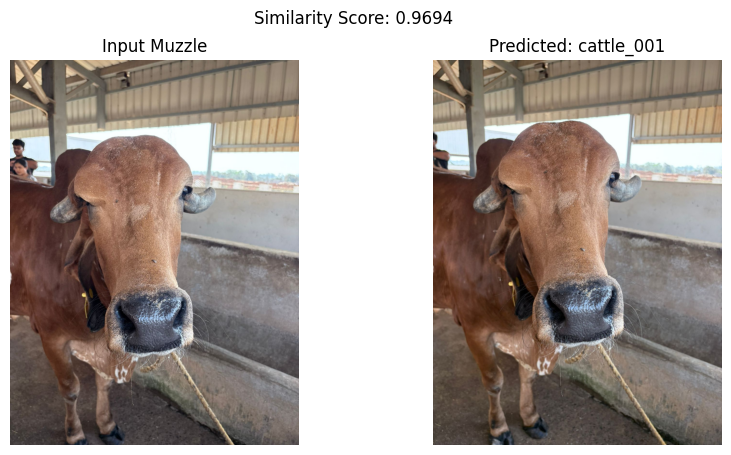

In [37]:
# ---------------- PATHS ----------------
dataset_path = r"C:\Users\God\Desktop\cow identification\Cow Identification using ML\Muzzle-Identifier-ML\data\real_cropped_newdataset"
full_cow_path = r"C:\Users\God\Desktop\cow identification\Cow Identification using ML\Muzzle-Identifier-ML\data\real_world_dataset"

input_image = r"C:\Users\God\Desktop\cow identification\Cow Identification using ML\Muzzle-Identifier-ML\data\test_data\WhatsApp Image 2026-02-20 at 3.202 PM.JPEG"

# ---------------- PREDICTION ----------------
input_embedding = get_embedding(input_image)

best_similarity = -1
best_cow = None

for cow_folder in os.listdir(dataset_path):
    cow_path = os.path.join(dataset_path, cow_folder)

    if not os.path.isdir(cow_path):
        continue

    images = os.listdir(cow_path)
    if len(images) == 0:
        continue

    sample_path = os.path.join(cow_path, images[0])
    sample_embedding = get_embedding(sample_path)

    similarity = F.cosine_similarity(input_embedding, sample_embedding)

    if similarity.item() > best_similarity:
        best_similarity = similarity.item()
        best_cow = cow_folder

# ---------------- THRESHOLD ----------------
THRESHOLD = 0.75

print("\nBest Similarity:", round(best_similarity, 4))

if best_similarity < THRESHOLD:
    print("🚫 Cow not in database")

    # Show input image only
    img = Image.open(input_image)
    plt.imshow(img)
    plt.title("Cow not in database")
    plt.axis("off")
    plt.show()

else:
    print("✅ Predicted Cow:", best_cow)

    # Load predicted full cow image
    real_folder = os.path.join(full_cow_path, best_cow)

    if os.path.exists(real_folder):
        real_images = os.listdir(real_folder)

        if len(real_images) > 0:
            real_image_path = os.path.join(real_folder, real_images[0])
            predicted_img = Image.open(real_image_path)

            # Show side-by-side
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))

            # Input image
            input_img = Image.open(input_image)
            ax[0].imshow(input_img)
            ax[0].set_title("Input Muzzle")
            ax[0].axis("off")

            # Predicted cow image
            ax[1].imshow(predicted_img)
            ax[1].set_title(f"Predicted: {best_cow}")
            ax[1].axis("off")

            plt.suptitle(f"Similarity Score: {round(best_similarity, 4)}")
            plt.show()
        else:
            print("No image inside predicted folder.")
    else:
        print("Folder not found:", real_folder)